In [6]:
"""
COMPLETE PHYSICS-GUIDED DOMAIN ADAPTATION FOR PIPELINE LEAK DETECTION
Run this entire cell to execute the full pipeline

Author: Muhammad Umar
Affiliation: University of Ulsan
"""

# ==================== IMPORTS ====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("="*80)
print("PHYSICS-GUIDED DOMAIN ADAPTATION FOR PIPELINE LEAK DETECTION")
print("="*80)
print(f"\nUsing device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

# ==================== CONFIGURATION ====================
class Config:
    # Paths
    DATA_DIR = r'F:\Pipeline Data\pipeline data'
    RESULTS_DIR = './results_pipeline'
    
    # Create directories
    os.makedirs(RESULTS_DIR, exist_ok=True)
    os.makedirs(f'{RESULTS_DIR}/models', exist_ok=True)
    os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
    
    # Data files
    DATA_FILES = {
        'Gas_13Bar': os.path.join(DATA_DIR, 'Gas_13Bar.csv'),
        'Gas_18Bar': os.path.join(DATA_DIR, 'Gas_18Bar.csv'),
        'Water_13Bar': os.path.join(DATA_DIR, 'Water_13Bar.csv'),
        'Water_18Bar': os.path.join(DATA_DIR, 'Water_18Bar.csv')
    }
    
    # Domain metadata
    DOMAIN_INFO = {
        'Gas_13Bar': {'fluid': 'gas', 'pressure': 13, 'fluid_id': 0, 'pressure_id': 0},
        'Gas_18Bar': {'fluid': 'gas', 'pressure': 18, 'fluid_id': 0, 'pressure_id': 1},
        'Water_13Bar': {'fluid': 'water', 'pressure': 13, 'fluid_id': 1, 'pressure_id': 0},
        'Water_18Bar': {'fluid': 'water', 'pressure': 18, 'fluid_id': 1, 'pressure_id': 1}
    }
    
    # Physics constants
    SPEED_OF_SOUND = {'gas': 340, 'water': 1480}  # m/s
    ACOUSTIC_IMPEDANCE = {'gas': 0.0004, 'water': 1.48}  # MRayl
    DENSITY = {'gas': 1.2, 'water': 1000}  # kg/m³
    
    # Signal parameters
    SAMPLING_RATE = 1e6  # 1 MHz
    SIGNAL_LENGTH = 12000
    
    # Model parameters
    FEATURE_DIM = 512
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    
    # Domain adaptation weights
    LAMBDA_DOMAIN_FLUID = 0.5
    LAMBDA_DOMAIN_PRESSURE = 0.3
    LAMBDA_PHYSICS = 0.2
    
    # Experimental setup
    SOURCE_DOMAINS = ['Gas_13Bar', 'Gas_18Bar', 'Water_13Bar']
    TARGET_DOMAIN = 'Water_18Bar'
    
    # Split ratios
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cfg = Config()

# ==================== DATA LOADING ====================
class PipelineDataset(Dataset):
    def __init__(self, signals, labels, domain_info):
        self.signals = torch.FloatTensor(signals)
        self.labels = torch.LongTensor(labels)
        self.fluid_ids = torch.LongTensor([domain_info['fluid_id']] * len(signals))
        self.pressure_ids = torch.LongTensor([domain_info['pressure_id']] * len(signals))
        self.pressure_values = torch.FloatTensor([domain_info['pressure']] * len(signals))
        self.fluid_type = domain_info['fluid']
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return {
            'signal': self.signals[idx].unsqueeze(0),  # (1, signal_length)
            'label': self.labels[idx],
            'fluid_id': self.fluid_ids[idx],
            'pressure_id': self.pressure_ids[idx],
            'pressure_value': self.pressure_values[idx],
            'fluid_type': self.fluid_type
        }

def load_domain_data(domain_name, normalize=True):
    print(f"Loading {domain_name}...")
    df = pd.read_csv(cfg.DATA_FILES[domain_name])
    
    feature_cols = [col for col in df.columns if col.startswith('f')]
    signals = df[feature_cols].values
    labels = df['label'].values
    
    if normalize:
        scaler = StandardScaler()
        signals = scaler.fit_transform(signals)
    
    domain_info = cfg.DOMAIN_INFO[domain_name]
    
    print(f"  Shape: {signals.shape}, Labels: {np.bincount(labels)}")
    return signals, labels, domain_info

def create_dataloaders(domain_names, batch_size=cfg.BATCH_SIZE):
    all_signals = []
    all_labels = []
    all_domain_info = []
    
    for domain_name in domain_names:
        signals, labels, domain_info = load_domain_data(domain_name)
        all_signals.append(signals)
        all_labels.append(labels)
        all_domain_info.extend([domain_info] * len(signals))
    
    all_signals = np.vstack(all_signals)
    all_labels = np.hstack(all_labels)
    
    # Split into train/val
    train_signals, val_signals, train_labels, val_labels, train_info, val_info = train_test_split(
        all_signals, all_labels, all_domain_info,
        test_size=cfg.VAL_RATIO / (cfg.TRAIN_RATIO + cfg.VAL_RATIO),
        random_state=SEED,
        stratify=all_labels
    )
    
    train_dataset = PipelineDataset(train_signals, train_labels, train_info[0])
    val_dataset = PipelineDataset(val_signals, val_labels, val_info[0])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"\nTrain: {len(train_dataset)} samples, Val: {len(val_dataset)} samples")
    return train_loader, val_loader

def create_target_loader(domain_name, batch_size=cfg.BATCH_SIZE):
    signals, labels, domain_info = load_domain_data(domain_name)
    dataset = PipelineDataset(signals, labels, domain_info)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return loader

# ==================== NEURAL NETWORK MODELS ====================

class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class FeatureExtractor1D(nn.Module):
    def __init__(self, input_channels=1, feature_dim=cfg.FEATURE_DIM):
        super(FeatureExtractor1D, self).__init__()
        
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, feature_dim)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [ResBlock1D(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResBlock1D(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class TaskClassifier(nn.Module):
    def __init__(self, feature_dim=cfg.FEATURE_DIM, num_classes=2):
        super(TaskClassifier, self).__init__()
        self.fc1 = nn.Linear(feature_dim, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, features):
        x = F.relu(self.fc1(features))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class DomainDiscriminator(nn.Module):
    def __init__(self, feature_dim=cfg.FEATURE_DIM, num_domains=2):
        super(DomainDiscriminator, self).__init__()
        self.fc1 = nn.Linear(feature_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_domains)
    
    def forward(self, features):
        x = F.relu(self.fc1(features))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_param):
        ctx.lambda_param = lambda_param
        return x.view_as(x)
    
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_param, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_param=1.0):
        super(GradientReversalLayer, self).__init__()
        self.lambda_param = lambda_param
    
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_param)

class PhysicsGuidedDomainAdaptation(nn.Module):
    def __init__(self, feature_dim=cfg.FEATURE_DIM):
        super(PhysicsGuidedDomainAdaptation, self).__init__()
        
        self.feature_extractor = FeatureExtractor1D(input_channels=1, feature_dim=feature_dim)
        self.task_classifier = TaskClassifier(feature_dim=feature_dim, num_classes=2)
        self.fluid_discriminator = DomainDiscriminator(feature_dim=feature_dim, num_domains=2)
        self.pressure_discriminator = DomainDiscriminator(feature_dim=feature_dim, num_domains=2)
        
        self.grl_fluid = GradientReversalLayer(lambda_param=cfg.LAMBDA_DOMAIN_FLUID)
        self.grl_pressure = GradientReversalLayer(lambda_param=cfg.LAMBDA_DOMAIN_PRESSURE)
    
    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        task_pred = self.task_classifier(features)
        
        fluid_features = self.grl_fluid(features)
        fluid_pred = self.fluid_discriminator(fluid_features)
        
        pressure_features = self.grl_pressure(features)
        pressure_pred = self.pressure_discriminator(pressure_features)
        
        if return_features:
            return task_pred, fluid_pred, pressure_pred, features
        else:
            return task_pred, fluid_pred, pressure_pred

class SimpleConv1D(nn.Module):
    """Baseline model without domain adaptation"""
    def __init__(self):
        super(SimpleConv1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 2)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ==================== PHYSICS LOSS ====================

def compute_physics_loss(features, pressure_values):
    """
    Physics constraint: Acoustic energy should scale with sqrt(pressure)
    """
    # Compute feature energy (L2 norm)
    feature_energy = torch.norm(features, p=2, dim=1)
    
    # Theoretical energy based on pressure
    pressure_ref = 13.0
    theoretical_energy = torch.sqrt(pressure_values / pressure_ref)
    
    # Normalize
    feature_energy_normalized = (feature_energy - feature_energy.mean()) / (feature_energy.std() + 1e-8)
    theoretical_energy_normalized = (theoretical_energy - theoretical_energy.mean()) / (theoretical_energy.std() + 1e-8)
    
    # MSE loss
    physics_loss = F.mse_loss(feature_energy_normalized, theoretical_energy_normalized)
    
    return physics_loss

# ==================== TRAINING FUNCTIONS ====================

def train_epoch_domain_adaptation(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    task_loss_total = 0
    fluid_loss_total = 0
    pressure_loss_total = 0
    physics_loss_total = 0
    
    correct = 0
    total = 0
    
    for batch in tqdm(train_loader, desc="Training", leave=False):
        signals = batch['signal'].to(device)
        labels = batch['label'].to(device)
        fluid_ids = batch['fluid_id'].to(device)
        pressure_ids = batch['pressure_id'].to(device)
        pressure_values = batch['pressure_value'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        task_pred, fluid_pred, pressure_pred, features = model(signals, return_features=True)
        
        # Task loss (leak detection)
        task_loss = F.cross_entropy(task_pred, labels)
        
        # Domain losses
        fluid_loss = F.cross_entropy(fluid_pred, fluid_ids)
        pressure_loss = F.cross_entropy(pressure_pred, pressure_ids)
        
        # Physics loss
        physics_loss = compute_physics_loss(features, pressure_values)
        
        # Total loss
        loss = task_loss + \
               cfg.LAMBDA_DOMAIN_FLUID * fluid_loss + \
               cfg.LAMBDA_DOMAIN_PRESSURE * pressure_loss + \
               cfg.LAMBDA_PHYSICS * physics_loss
        
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        task_loss_total += task_loss.item()
        fluid_loss_total += fluid_loss.item()
        pressure_loss_total += pressure_loss.item()
        physics_loss_total += physics_loss.item()
        
        _, predicted = task_pred.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(train_loader)
    
    return {
        'loss': avg_loss,
        'task_loss': task_loss_total / len(train_loader),
        'fluid_loss': fluid_loss_total / len(train_loader),
        'pressure_loss': pressure_loss_total / len(train_loader),
        'physics_loss': physics_loss_total / len(train_loader),
        'accuracy': accuracy
    }

def train_epoch_baseline(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(train_loader, desc="Training", leave=False):
        signals = batch['signal'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(signals)
        loss = F.cross_entropy(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(train_loader)
    
    return {'loss': avg_loss, 'accuracy': accuracy}

def evaluate(model, data_loader, device, is_domain_adaptation=True):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in data_loader:
            signals = batch['signal'].to(device)
            labels = batch['label'].to(device)
            
            if is_domain_adaptation:
                task_pred, _, _ = model(signals)
            else:
                task_pred = model(signals)
            
            probs = F.softmax(task_pred, dim=1)
            _, predicted = task_pred.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    return {
        'accuracy': accuracy * 100,
        'precision': precision * 100,
        'recall': recall * 100,
        'f1': f1 * 100,
        'auc': auc,
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs
    }

# ==================== VISUALIZATION ====================

def plot_confusion_matrix(labels, predictions, title, save_path):
    cm = confusion_matrix(labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Leak'], 
                yticklabels=['Normal', 'Leak'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {save_path}")

def plot_training_history(history, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[0, 1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Domain losses (if available)
    if 'fluid_loss' in history:
        axes[1, 0].plot(history['fluid_loss'], label='Fluid Loss', marker='o')
        axes[1, 0].plot(history['pressure_loss'], label='Pressure Loss', marker='s')
        axes[1, 0].plot(history['physics_loss'], label='Physics Loss', marker='^')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Domain Adaptation Losses')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # ROC curve placeholder
    axes[1, 1].text(0.5, 0.5, 'See separate ROC plot', 
                   ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('ROC Curve')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {save_path}")

def plot_roc_curve(labels, probs, title, save_path):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {save_path}")

# ==================== MAIN EXECUTION ====================

def main():
    print("\n" + "="*80)
    print("STARTING EXPERIMENTS")
    print("="*80)
    
    # Load data
    print("\n[1/4] Loading Data...")
    train_loader, val_loader = create_dataloaders(cfg.SOURCE_DOMAINS, cfg.BATCH_SIZE)
    target_loader = create_target_loader(cfg.TARGET_DOMAIN, cfg.BATCH_SIZE)
    
    # ==================== EXPERIMENT 1: BASELINE CNN ====================
    print("\n[2/4] Training Baseline CNN (No Domain Adaptation)...")
    baseline_model = SimpleConv1D().to(cfg.DEVICE)
    baseline_optimizer = optim.Adam(baseline_model.parameters(), 
                                   lr=cfg.LEARNING_RATE, 
                                   weight_decay=cfg.WEIGHT_DECAY)
    
    baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(cfg.NUM_EPOCHS):
        train_metrics = train_epoch_baseline(baseline_model, train_loader, baseline_optimizer, cfg.DEVICE)
        val_metrics = evaluate(baseline_model, val_loader, cfg.DEVICE, is_domain_adaptation=False)
        
        baseline_history['train_loss'].append(train_metrics['loss'])
        baseline_history['train_acc'].append(train_metrics['accuracy'])
        baseline_history['val_loss'].append(train_metrics['loss'])
        baseline_history['val_acc'].append(val_metrics['accuracy'])
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{cfg.NUM_EPOCHS} - "
                  f"Train Acc: {train_metrics['accuracy']:.2f}%, "
                  f"Val Acc: {val_metrics['accuracy']:.2f}%")
    
    # Evaluate baseline on target domain
    print("\n  Evaluating Baseline on Target Domain (Water_18Bar)...")
    baseline_target_metrics = evaluate(baseline_model, target_loader, cfg.DEVICE, is_domain_adaptation=False)
    
    print(f"\n  BASELINE RESULTS ON TARGET DOMAIN:")
    print(f"    Accuracy: {baseline_target_metrics['accuracy']:.2f}%")
    print(f"    Precision: {baseline_target_metrics['precision']:.2f}%")
    print(f"    Recall: {baseline_target_metrics['recall']:.2f}%")
    print(f"    F1-Score: {baseline_target_metrics['f1']:.2f}%")
    print(f"    AUC: {baseline_target_metrics['auc']:.4f}")
    
    # ==================== EXPERIMENT 2: PHYSICS-GUIDED DOMAIN ADAPTATION ====================
    print("\n[3/4] Training Physics-Guided Domain Adaptation Model...")
    pgda_model = PhysicsGuidedDomainAdaptation(feature_dim=cfg.FEATURE_DIM).to(cfg.DEVICE)
    pgda_optimizer = optim.Adam(pgda_model.parameters(), 
                               lr=cfg.LEARNING_RATE, 
                               weight_decay=cfg.WEIGHT_DECAY)
    
    pgda_history = {
        'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
        'fluid_loss': [], 'pressure_loss': [], 'physics_loss': []
    }
    
    for epoch in range(cfg.NUM_EPOCHS):
        train_metrics = train_epoch_domain_adaptation(pgda_model, train_loader, pgda_optimizer, cfg.DEVICE)
        val_metrics = evaluate(pgda_model, val_loader, cfg.DEVICE, is_domain_adaptation=True)
        
        pgda_history['train_loss'].append(train_metrics['loss'])
        pgda_history['train_acc'].append(train_metrics['accuracy'])
        pgda_history['val_loss'].append(train_metrics['task_loss'])
        pgda_history['val_acc'].append(val_metrics['accuracy'])
        pgda_history['fluid_loss'].append(train_metrics['fluid_loss'])
        pgda_history['pressure_loss'].append(train_metrics['pressure_loss'])
        pgda_history['physics_loss'].append(train_metrics['physics_loss'])
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{cfg.NUM_EPOCHS} - "
                  f"Train Acc: {train_metrics['accuracy']:.2f}%, "
                  f"Val Acc: {val_metrics['accuracy']:.2f}%")
    
    # Evaluate PGDA on target domain
    print("\n  Evaluating PGDA on Target Domain (Water_18Bar)...")
    pgda_target_metrics = evaluate(pgda_model, target_loader, cfg.DEVICE, is_domain_adaptation=True)
    
    print(f"\n  PGDA RESULTS ON TARGET DOMAIN:")
    print(f"    Accuracy: {pgda_target_metrics['accuracy']:.2f}%")
    print(f"    Precision: {pgda_target_metrics['precision']:.2f}%")
    print(f"    Recall: {pgda_target_metrics['recall']:.2f}%")
    print(f"    F1-Score: {pgda_target_metrics['f1']:.2f}%")
    print(f"    AUC: {pgda_target_metrics['auc']:.4f}")
    
    # ==================== RESULTS COMPARISON ====================
    print("\n[4/4] Generating Results and Visualizations...")
    
    print("\n" + "="*80)
    print("FINAL COMPARISON: BASELINE vs PHYSICS-GUIDED DOMAIN ADAPTATION")
    print("="*80)
    
    results_df = pd.DataFrame({
        'Method': ['Baseline CNN', 'Physics-Guided DA'],
        'Accuracy (%)': [baseline_target_metrics['accuracy'], pgda_target_metrics['accuracy']],
        'Precision (%)': [baseline_target_metrics['precision'], pgda_target_metrics['precision']],
        'Recall (%)': [baseline_target_metrics['recall'], pgda_target_metrics['recall']],
        'F1-Score (%)': [baseline_target_metrics['f1'], pgda_target_metrics['f1']],
        'AUC': [baseline_target_metrics['auc'], pgda_target_metrics['auc']]
    })
    
    print("\n" + results_df.to_string(index=False))
    
    improvement = pgda_target_metrics['accuracy'] - baseline_target_metrics['accuracy']
    print(f"\n✓ IMPROVEMENT: +{improvement:.2f}% accuracy on unseen target domain!")
    
    # Save results table
    results_df.to_csv(f'{cfg.RESULTS_DIR}/comparison_results.csv', index=False)
    print(f"\nSaved: {cfg.RESULTS_DIR}/comparison_results.csv")
    
    # ==================== VISUALIZATIONS ====================
    
    # Confusion matrices
    plot_confusion_matrix(
        baseline_target_metrics['labels'], 
        baseline_target_metrics['predictions'],
        'Baseline CNN - Confusion Matrix (Water_18Bar)',
        f'{cfg.RESULTS_DIR}/figures/baseline_confusion_matrix.png'
    )
    
    plot_confusion_matrix(
        pgda_target_metrics['labels'], 
        pgda_target_metrics['predictions'],
        'Physics-Guided DA - Confusion Matrix (Water_18Bar)',
        f'{cfg.RESULTS_DIR}/figures/pgda_confusion_matrix.png'
    )
    
    # Training history
    plot_training_history(
        baseline_history,
        f'{cfg.RESULTS_DIR}/figures/baseline_training_history.png'
    )
    
    plot_training_history(
        pgda_history,
        f'{cfg.RESULTS_DIR}/figures/pgda_training_history.png'
    )
    
    # ROC curves
    plot_roc_curve(
        baseline_target_metrics['labels'],
        baseline_target_metrics['probs'],
        'Baseline CNN - ROC Curve (Water_18Bar)',
        f'{cfg.RESULTS_DIR}/figures/baseline_roc_curve.png'
    )
    
    plot_roc_curve(
        pgda_target_metrics['labels'],
        pgda_target_metrics['probs'],
        'Physics-Guided DA - ROC Curve (Water_18Bar)',
        f'{cfg.RESULTS_DIR}/figures/pgda_roc_curve.png'
    )
    
    # Comparison bar chart
    plt.figure(figsize=(10, 6))
    x = np.arange(len(results_df))
    width = 0.35
    
    metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(metrics))
    
    baseline_values = [baseline_target_metrics['accuracy'], 
                      baseline_target_metrics['precision'],
                      baseline_target_metrics['recall'],
                      baseline_target_metrics['f1']]
    
    pgda_values = [pgda_target_metrics['accuracy'],
                  pgda_target_metrics['precision'],
                  pgda_target_metrics['recall'],
                  pgda_target_metrics['f1']]
    
    ax.bar(x_pos - width/2, baseline_values, width, label='Baseline CNN', alpha=0.8)
    ax.bar(x_pos + width/2, pgda_values, width, label='Physics-Guided DA', alpha=0.8)
    
    ax.set_ylabel('Score (%)', fontweight='bold')
    ax.set_title('Performance Comparison on Target Domain (Water_18Bar)', fontweight='bold', fontsize=14)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (baseline_val, pgda_val) in enumerate(zip(baseline_values, pgda_values)):
        ax.text(i - width/2, baseline_val + 1, f'{baseline_val:.1f}', 
               ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, pgda_val + 1, f'{pgda_val:.1f}', 
               ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{cfg.RESULTS_DIR}/figures/performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {cfg.RESULTS_DIR}/figures/performance_comparison.png")
    
    # Save models
    torch.save(baseline_model.state_dict(), f'{cfg.RESULTS_DIR}/models/baseline_model.pth')
    torch.save(pgda_model.state_dict(), f'{cfg.RESULTS_DIR}/models/pgda_model.pth')
    print(f"\nSaved models to: {cfg.RESULTS_DIR}/models/")
    
    print("\n" + "="*80)
    print("EXPERIMENT COMPLETED SUCCESSFULLY!")
    print("="*80)
    print(f"\nAll results saved to: {cfg.RESULTS_DIR}/")
    print(f"  - Comparison table: comparison_results.csv")
    print(f"  - Figures: figures/")
    print(f"  - Models: models/")
    
    print("\n🎉 CONGRATULATIONS UMAR! YOUR MSSP PAPER IS READY!")
    print(f"   Main Result: {improvement:.2f}% accuracy improvement with physics-guided domain adaptation")
    print(f"   Baseline: {baseline_target_metrics['accuracy']:.2f}% → PGDA: {pgda_target_metrics['accuracy']:.2f}%")

# ==================== RUN EVERYTHING ====================
if __name__ == "__main__":
    main()

PHYSICS-GUIDED DOMAIN ADAPTATION FOR PIPELINE LEAK DETECTION

Using device: CUDA

STARTING EXPERIMENTS

[1/4] Loading Data...
Loading Gas_13Bar...
  Shape: (360, 12000), Labels: [120 240]
Loading Gas_18Bar...
  Shape: (360, 12000), Labels: [120 240]
Loading Water_13Bar...
  Shape: (360, 12000), Labels: [120 240]

Train: 889 samples, Val: 191 samples
Loading Water_18Bar...
  Shape: (360, 12000), Labels: [120 240]

[2/4] Training Baseline CNN (No Domain Adaptation)...


  Epoch 10/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 20/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 30/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 40/50 - Train Acc: 100.00%, Val Acc: 100.00%


...

  Epoch 20/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 30/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 40/50 - Train Acc: 100.00%, Val Acc: 100.00%


  Epoch 50/50 - Train Acc: 100.00%, Val Acc: 100.00%

  Evaluating PGDA on Target Domain (Water_18Bar)...

  PGDA RESULTS ON TARGET DOMAIN:
    Accuracy: 99.44%
    Precision: 100.00%
    Recall: 99.17%
    F1-Score: 99.58%
    AUC: 1.0000

[4/4] Generating Results and Visualizations...

FINAL COMPARISON: BASELINE vs PHYSICS-GUIDED DOMAIN ADAPTATION

           Method  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC
     Baseline CNN     99.444444          100.0   99.166667      99.58159  1.0
Physics-Guided DA     99.444444          100.0   99.166667      99.58159  1.0

✓ IMPROVEMENT: +0.00% accuracy on unseen target domain!

Saved: ./results_pipeline/comparison_results.csv
Saved: ./results_pipeline/figures/baseline_confusion_matrix.png
Saved: ./results_pipeline/figures/pgda_confusion_matrix.png
Saved: ./results_pipeline/figures/baseline_training_history.png
Saved: ./results_pipeline/figures/pgda_training_history.png
Saved: ./results_pipeline/figures/baseline_roc_curve.png
S

<Figure size 3000x1800 with 0 Axes>

In [17]:
"""
SHSE File Reader - Correct Implementation
Based on official MATLAB shseRead function

File Structure:
- Bytes 0-13:   Timestamp (14 bytes, ASCII)
- Bytes 14-21:  Sampling rate (double, 8 bytes)
- Byte 22:      Number of channels (uint8, 1 byte)
- Bytes 23-30:  Number of samples per channel (double, 8 bytes)
- Bytes 31+:    Signal data (double precision, 8 bytes per sample, channel-interleaved)
"""

import numpy as np
import struct
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
import os


def read_shse_file(filepath, time_range=None, channel=None):
    """
    Read .shse file - correct implementation
    
    Parameters:
    -----------
    filepath : str
        Path to .shse file
    time_range : tuple or None
        (start_time, end_time) in seconds. None = read all
    channel : int or None
        Channel number (0-indexed). None = read all channels
    
    Returns:
    --------
    signals : numpy array
        Signal data (samples x channels)
    metadata : dict
        File metadata
    """
    
    with open(filepath, 'rb') as f:
        # Read header
        timestamp = f.read(14).decode('ascii', errors='ignore')
        fs = struct.unpack('d', f.read(8))[0]  # double
        Nc = struct.unpack('B', f.read(1))[0]  # uint8
        NSPC = struct.unpack('d', f.read(8))[0]  # double (Number of Samples Per Channel)
        
        header_end = f.tell()  # Should be 31 bytes
        
        print(f"File: {os.path.basename(filepath)}")
        print(f"Timestamp: {timestamp}")
        print(f"Sampling Rate: {fs/1e6:.1f} MHz ({fs:.0f} Hz)")
        print(f"Number of Channels: {Nc}")
        print(f"Samples per Channel: {int(NSPC):,}")
        print(f"Duration: {NSPC/fs:.2f} seconds ({NSPC/fs/60:.2f} minutes)")
        print(f"Header size: {header_end} bytes\n")
        
        # Determine what to read
        if time_range is None:
            # Read all data
            total_samples = int(NSPC)
            start_sample = 0
        else:
            start_time, end_time = time_range
            start_sample = int(start_time * fs)
            end_sample = int(end_time * fs)
            total_samples = end_sample - start_sample
            
            # Seek to start position
            f.seek(header_end + start_sample * 8 * Nc)
        
        # Read signal data
        print(f"Reading {total_samples:,} samples...")
        
        # Data is interleaved: [ch1_s1, ch2_s1, ..., chN_s1, ch1_s2, ch2_s2, ...]
        data = np.fromfile(f, dtype=np.float64, count=total_samples * Nc)
        
        # Reshape to (samples, channels)
        signals = data.reshape((total_samples, Nc), order='C')
        
        # Select specific channel if requested
        if channel is not None:
            if channel >= Nc:
                raise ValueError(f"Channel {channel} not available. File has {Nc} channels.")
            signals = signals[:, channel:channel+1]
    
    # Create metadata
    metadata = {
        'timestamp': timestamp,
        'sampling_rate': fs,
        'num_channels': Nc,
        'samples_per_channel': int(NSPC),
        'duration_sec': NSPC / fs,
        'total_samples_read': total_samples,
        'header_size': 31
    }
    
    # Print statistics for each channel
    print("="*60)
    print("SIGNAL STATISTICS")
    print("="*60)
    for ch in range(signals.shape[1]):
        ch_signal = signals[:, ch]
        print(f"\nChannel {ch}:")
        print(f"  Samples: {len(ch_signal):,}")
        print(f"  Mean: {np.mean(ch_signal):.6e}")
        print(f"  Std: {np.std(ch_signal):.6e}")
        print(f"  Min: {np.min(ch_signal):.6e}")
        print(f"  Max: {np.max(ch_signal):.6e}")
        print(f"  RMS: {np.sqrt(np.mean(ch_signal**2)):.6e}")
    print("="*60 + "\n")
    
    return signals, metadata


def plot_shse_signal(signals, metadata, channel=0, duration=2.0, save_path='shse_analysis.png'):
    """
    Create comprehensive visualization of SHSE signal
    
    Parameters:
    -----------
    signals : numpy array
        Signal data (samples x channels)
    metadata : dict
        Metadata from read_shse_file
    channel : int
        Channel to plot (0-indexed)
    duration : float
        Duration to plot in seconds
    save_path : str
        Output file path
    """
    
    fs = metadata['sampling_rate']
    
    # Select channel
    if signals.ndim == 1:
        signal = signals
    else:
        if channel >= signals.shape[1]:
            channel = 0
        signal = signals[:, channel]
    
    print(f"Creating visualization for Channel {channel}...")
    
    # Create figure
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Time domain - full duration
    ax1 = fig.add_subplot(gs[0, :])
    n_samples = min(int(duration * fs), len(signal))
    t = np.arange(n_samples) / fs
    ax1.plot(t, signal[:n_samples], linewidth=0.5, color='navy', alpha=0.8)
    ax1.set_xlabel('Time (s)', fontsize=10)
    ax1.set_ylabel('Amplitude', fontsize=10)
    ax1.set_title(f'Time Domain - Channel {channel} - First {duration}s', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Statistics text
    stats_text = f'Mean: {np.mean(signal[:n_samples]):.2e} | Std: {np.std(signal[:n_samples]):.2e} | RMS: {np.sqrt(np.mean(signal[:n_samples]**2)):.2e}'
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Zoomed view
    ax2 = fig.add_subplot(gs[1, 0])
    zoom_duration = 0.01  # 10 ms
    n_zoom = int(zoom_duration * fs)
    t_zoom = np.arange(n_zoom) / fs * 1000
    ax2.plot(t_zoom, signal[:n_zoom], linewidth=0.8, color='darkgreen')
    ax2.set_xlabel('Time (ms)', fontsize=10)
    ax2.set_ylabel('Amplitude', fontsize=10)
    ax2.set_title('Zoomed - First 10ms', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Histogram
    ax3 = fig.add_subplot(gs[1, 1])
    # Use a subset for histogram (first 1M samples)
    hist_samples = signal[:min(1000000, len(signal))]
    ax3.hist(hist_samples, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Amplitude', fontsize=10)
    ax3.set_ylabel('Count', fontsize=10)
    ax3.set_title('Amplitude Distribution', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Power Spectral Density
    ax4 = fig.add_subplot(gs[2, 0])
    segment = signal[:min(int(fs), len(signal))]
    f, pxx = sp_signal.welch(segment, fs=fs, nperseg=4096, noverlap=2048)
    ax4.semilogy(f/1e3, pxx, color='darkred', linewidth=1.5)
    ax4.set_xlabel('Frequency (kHz)', fontsize=10)
    ax4.set_ylabel('PSD (V²/Hz)', fontsize=10)
    ax4.set_title('Power Spectral Density', fontsize=11, fontweight='bold')
    ax4.set_xlim([0, min(500, fs/2000)])  # Up to 500 kHz or Nyquist
    ax4.grid(True, alpha=0.3)
    
    # 5. Spectrogram
    ax5 = fig.add_subplot(gs[2, 1])
    spec_duration = 0.1  # 100 ms
    n_spec = min(int(spec_duration * fs), len(signal))
    f_spec, t_spec, Sxx = sp_signal.spectrogram(signal[:n_spec], fs=fs,
                                                 nperseg=1024, noverlap=512)
    
    # Limit to reasonable frequency
    max_freq = min(500e3, fs/2)
    freq_mask = f_spec <= max_freq
    
    im = ax5.pcolormesh(t_spec*1000, f_spec[freq_mask]/1e3,
                        10*np.log10(Sxx[freq_mask, :] + 1e-20),
                        shading='gouraud', cmap='viridis')
    ax5.set_xlabel('Time (ms)', fontsize=10)
    ax5.set_ylabel('Frequency (kHz)', fontsize=10)
    ax5.set_title('Spectrogram - First 100ms', fontsize=11, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax5)
    cbar.set_label('Power (dB)', fontsize=9)
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Visualization saved to: {save_path}\n")
    plt.close()


def extract_ae_features(signal, fs):
    """Extract acoustic emission features"""
    
    features = {}
    
    # Time domain
    features['RMS'] = np.sqrt(np.mean(signal**2))
    features['Peak'] = np.max(np.abs(signal))
    features['Mean'] = np.mean(signal)
    features['Std'] = np.std(signal)
    features['Crest_Factor'] = features['Peak'] / (features['RMS'] + 1e-20)
    
    # Normalized moments
    signal_norm = (signal - features['Mean']) / (features['Std'] + 1e-20)
    features['Kurtosis'] = np.mean(signal_norm**4)
    features['Skewness'] = np.mean(signal_norm**3)
    
    # Frequency domain
    segment = signal[:min(int(fs), len(signal))]
    f, pxx = sp_signal.welch(segment, fs=fs, nperseg=4096)
    
    features['Peak_Frequency'] = f[np.argmax(pxx)]
    features['Mean_Frequency'] = np.sum(f * pxx) / np.sum(pxx)
    features['Spectral_Centroid'] = features['Mean_Frequency']
    
    print("EXTRACTED FEATURES")
    print("="*60)
    print(f"RMS: {features['RMS']:.6e}")
    print(f"Peak: {features['Peak']:.6e}")
    print(f"Crest Factor: {features['Crest_Factor']:.4f}")
    print(f"Kurtosis: {features['Kurtosis']:.4f}")
    print(f"Peak Frequency: {features['Peak_Frequency']/1e3:.2f} kHz")
    print(f"Mean Frequency: {features['Mean_Frequency']/1e3:.2f} kHz")
    print("="*60 + "\n")
    
    return features


# ============================================================
# MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    
    # File path
    FILEPATH = r"C:\Users\Muhammad Umar\Downloads\0.3mm_Gas_7Bar.shse"
    
    print("\n" + "="*60)
    print("SHSE FILE READER - CORRECT VERSION")
    print("Based on official MATLAB shseRead function")
    print("="*60 + "\n")
    
    # Step 1: Read the file
    # Read all data from all channels
    signals, metadata = read_shse_file(FILEPATH)
    
    # Or read only first 10 seconds:
    # signals, metadata = read_shse_file(FILEPATH, time_range=(0, 10))
    
    # Or read only channel 0:
    # signals, metadata = read_shse_file(FILEPATH, channel=0)
    
    # Step 2: Visualize (channel 0)
    plot_shse_signal(signals, metadata, channel=0, duration=2.0,
                    save_path='shse_analysis_ch0.png')
    
    # Step 3: Extract features from channel 0
    if signals.ndim == 1:
        signal_ch0 = signals
    else:
        signal_ch0 = signals[:, 0]
    
    features = extract_ae_features(signal_ch0, metadata['sampling_rate'])
    
    # Step 4: Save processed data (optional)
    # np.save('ae_signal_0.3mm_gas_7bar.npy', signals)
    # print("✓ Signal saved to: ae_signal_0.3mm_gas_7bar.npy")
    
    print("="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print("\nKey Information:")
    print(f"  File: {os.path.basename(FILEPATH)}")
    print(f"  Channels: {metadata['num_channels']}")
    print(f"  Duration: {metadata['duration_sec']/60:.2f} minutes")
    print(f"  Sampling Rate: {metadata['sampling_rate']/1e6:.1f} MHz")
    print(f"  Total Samples: {metadata['samples_per_channel']:,} per channel")
    print("="*60 + "\n")


SHSE FILE READER - CORRECT VERSION
Based on official MATLAB shseRead function

File: 0.3mm_Gas_7Bar.shse
Timestamp: 20180821114958
Sampling Rate: 1.0 MHz (1000000 Hz)
Number of Channels: 3
Samples per Channel: 360,000,000
Duration: 360.00 seconds (6.00 minutes)
Header size: 31 bytes

Reading 360,000,000 samples...
SIGNAL STATISTICS

Channel 0:
  Samples: 360,000,000
  Mean: 4.464008e-02
  Std: 6.456964e-02
  Min: -1.615701e-01
  Max: 2.484483e-01
  RMS: 7.849825e-02

Channel 1:
  Samples: 360,000,000
  Mean: 4.463974e-02
  Std: 6.457032e-02
  Min: -1.622166e-01
  Max: 2.594419e-01
  RMS: 7.849861e-02

Channel 2:
  Samples: 360,000,000
  Mean: 4.463955e-02
  Std: 6.457009e-02
  Min: -1.363560e-01
  Max: 2.526517e-01
  RMS: 7.849832e-02

Creating visualization for Channel 0...
✓ Visualization saved to: shse_analysis_ch0.png

EXTRACTED FEATURES
RMS: 7.849825e-02
Peak: 2.484483e-01
Crest Factor: 3.1650
Kurtosis: 1.7129
Peak Frequency: 0.24 kHz
Mean Frequency: 242.83 kHz

ANALYSIS COMPLETE

In [21]:
"""
Debug and fix visualization script
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def check_columns(csv_path):
    """Check what columns are in the CSV"""
    print("="*60)
    print("CHECKING CSV COLUMNS")
    print("="*60)
    
    df = pd.read_csv(csv_path)
    
    print(f"\nDataFrame shape: {df.shape}")
    print(f"\nAll columns ({len(df.columns)}):")
    print("-"*60)
    
    # Group columns by prefix
    meta_cols = [col for col in df.columns if not col.startswith('ch')]
    ch0_cols = [col for col in df.columns if col.startswith('ch0_')]
    ch1_cols = [col for col in df.columns if col.startswith('ch1_')]
    ch2_cols = [col for col in df.columns if col.startswith('ch2_')]
    
    print(f"\nMetadata columns ({len(meta_cols)}):")
    for col in meta_cols:
        print(f"  - {col}")
    
    print(f"\nChannel 0 features ({len(ch0_cols)}):")
    for col in sorted(ch0_cols):
        print(f"  - {col}")
    
    print(f"\nChannel 1 features ({len(ch1_cols)}):")
    print(f"  (Similar to Channel 0: {len(ch1_cols)} features)")
    
    print(f"\nChannel 2 features ({len(ch2_cols)}):")
    print(f"  (Similar to Channel 0: {len(ch2_cols)} features)")
    
    return df, ch0_cols


def create_basic_visualizations(df, output_dir='./visualizations'):
    """
    Create visualizations that work with whatever columns exist
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Get available feature columns
    feature_cols = [col for col in df.columns if col.startswith('ch0_')]
    
    if len(feature_cols) == 0:
        print("⚠ No feature columns found!")
        return
    
    print(f"\n{'='*60}")
    print(f"CREATING VISUALIZATIONS")
    print(f"{'='*60}\n")
    
    # Select a few key features that should exist
    key_features = []
    desired_features = ['ch0_rms', 'ch0_peak', 'ch0_crest_factor', 'ch0_kurtosis', 
                       'ch0_std', 'ch0_mean', 'ch0_energy', 'ch0_skewness']
    
    for feat in desired_features:
        if feat in feature_cols:
            key_features.append(feat)
    
    if len(key_features) < 4:
        key_features = feature_cols[:min(8, len(feature_cols))]
    
    print(f"Using features: {key_features}\n")
    
    # ============================================================
    # PLOT 1: Feature distributions by leak size
    # ============================================================
    n_features = min(8, len(key_features))
    n_rows = (n_features + 1) // 2
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, feature in enumerate(key_features[:n_features]):
        ax = axes[idx]
        
        # Get unique leak sizes
        leak_sizes = sorted(df['leak_size_mm'].unique())
        
        if len(leak_sizes) > 1:
            for leak_size in leak_sizes:
                data = df[df['leak_size_mm'] == leak_size][feature]
                ax.hist(data, alpha=0.6, bins=20, label=f'{leak_size}mm', density=True)
            ax.legend(fontsize=8)
        else:
            # Just one leak size
            data = df[feature]
            ax.hist(data, bins=20, alpha=0.7, color='steelblue')
        
        feature_name = feature.replace('ch0_', '').replace('_', ' ').title()
        ax.set_xlabel(feature_name, fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Feature Distributions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(output_dir, 'feature_distributions.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    # ============================================================
    # PLOT 2: Box plots comparing conditions
    # ============================================================
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    # Prepare data
    df_plot = df.copy()
    df_plot['leak_size'] = df_plot['leak_size_mm'].astype(str) + 'mm'
    df_plot['pressure'] = df_plot['pressure_bar'].astype(str) + ' bar'
    
    # Use first 4 available features
    plot_features = key_features[:min(4, len(key_features))]
    
    for idx, feature in enumerate(plot_features):
        ax = axes[idx]
        
        # Decide what to plot based on data diversity
        leak_sizes = df_plot['leak_size'].unique()
        media_types = df_plot['media'].unique()
        pressures = df_plot['pressure'].unique()
        
        if len(leak_sizes) > 1:
            # Plot by leak size
            sns.boxplot(data=df_plot, x='leak_size', y=feature, ax=ax)
            ax.set_xlabel('Leak Size')
            title_suffix = 'vs Leak Size'
        elif len(media_types) > 1:
            # Plot by media
            sns.boxplot(data=df_plot, x='media', y=feature, ax=ax)
            ax.set_xlabel('Media Type')
            title_suffix = 'vs Media'
        elif len(pressures) > 1:
            # Plot by pressure
            sns.boxplot(data=df_plot, x='pressure', y=feature, ax=ax)
            ax.set_xlabel('Pressure')
            title_suffix = 'vs Pressure'
        else:
            # Only one condition - just show distribution
            ax.hist(df_plot[feature], bins=20, alpha=0.7, color='steelblue')
            ax.set_xlabel(feature.replace('ch0_', '').replace('_', ' ').title())
            title_suffix = 'Distribution'
        
        feature_name = feature.replace('ch0_', '').replace('_', ' ').title()
        ax.set_title(f'{feature_name} {title_suffix}', fontweight='bold', fontsize=10)
        ax.set_ylabel(feature_name)
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    save_path = os.path.join(output_dir, 'feature_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    # ============================================================
    # PLOT 3: Correlation heatmap (top features only)
    # ============================================================
    # Select top 20 features by variance
    feature_vars = df[feature_cols].var().sort_values(ascending=False)
    top_features = feature_vars.head(min(20, len(feature_cols))).index.tolist()
    
    corr = df[top_features].corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, annot=False)
    
    # Simplify labels
    labels = [col.replace('ch0_', '') for col in top_features]
    plt.xticks(np.arange(len(labels)) + 0.5, labels, rotation=90, fontsize=8)
    plt.yticks(np.arange(len(labels)) + 0.5, labels, rotation=0, fontsize=8)
    
    plt.title('Feature Correlation Matrix (Top 20)', fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    save_path = os.path.join(output_dir, 'correlation_heatmap.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    # ============================================================
    # PLOT 4: Feature importance (variance proxy)
    # ============================================================
    top_n = min(15, len(feature_cols))
    feature_vars_norm = (df[feature_cols].var() / df[feature_cols].var().sum()).sort_values(ascending=True).tail(top_n)
    
    plt.figure(figsize=(10, 6))
    feature_vars_norm.plot(kind='barh', color='steelblue')
    
    # Simplify labels
    ax = plt.gca()
    labels = [label.get_text().replace('ch0_', '') for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.xlabel('Normalized Variance', fontsize=10)
    plt.ylabel('Feature', fontsize=10)
    plt.title(f'Top {top_n} Features by Variance', fontweight='bold', fontsize=11)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    save_path = os.path.join(output_dir, 'feature_importance.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    print(f"\n{'='*60}")
    print("ALL VISUALIZATIONS COMPLETE!")
    print(f"{'='*60}\n")


def generate_summary_report(df, output_file='./visualizations/summary_report.txt'):
    """Generate text summary of the dataset"""
    
    with open(output_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("PIPELINE LEAK DETECTION - DATASET SUMMARY\n")
        f.write("="*60 + "\n\n")
        
        f.write(f"Total samples: {len(df)}\n")
        f.write(f"Total features: {len([col for col in df.columns if col.startswith('ch')])}\n\n")
        
        f.write("Dataset Composition:\n")
        f.write("-"*60 + "\n")
        f.write(f"Leak sizes: {sorted(df['leak_size_mm'].unique())} mm\n")
        f.write(f"Media types: {sorted(df['media'].unique())}\n")
        f.write(f"Pressures: {sorted(df['pressure_bar'].unique())} bar\n\n")
        
        f.write("Samples per condition:\n")
        f.write("-"*60 + "\n")
        class_counts = df.groupby(['leak_size_mm', 'media', 'pressure_bar']).size()
        f.write(str(class_counts) + "\n\n")
        
        # Feature statistics
        feature_cols = [col for col in df.columns if col.startswith('ch0_')][:10]
        if len(feature_cols) > 0:
            f.write("Sample feature statistics (Channel 0, first 10 features):\n")
            f.write("-"*60 + "\n")
            f.write(str(df[feature_cols].describe()) + "\n\n")
        
        # Top features by variance
        if len(feature_cols) > 0:
            all_ch0_features = [col for col in df.columns if col.startswith('ch0_')]
            feature_vars = df[all_ch0_features].var().sort_values(ascending=False).head(10)
            f.write("Top 10 features by variance:\n")
            f.write("-"*60 + "\n")
            for feat, var in feature_vars.items():
                f.write(f"{feat}: {var:.6e}\n")
    
    print(f"✓ Saved summary report: {output_file}\n")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    
    CSV_PATH = "./leak_detection_features/leak_detection_features.csv"
    OUTPUT_DIR = "./visualizations"
    
    print("\n" + "="*60)
    print("LEAK DETECTION FEATURE ANALYSIS - DEBUG VERSION")
    print("="*60 + "\n")
    
    # Check columns
    df, ch0_cols = check_columns(CSV_PATH)
    
    # Create visualizations
    create_basic_visualizations(df, OUTPUT_DIR)
    
    # Generate report
    generate_summary_report(df, os.path.join(OUTPUT_DIR, 'summary_report.txt'))
    
    print("="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print(f"\nGenerated files in {OUTPUT_DIR}/:")
    print("  - feature_distributions.png")
    print("  - feature_comparison.png")
    print("  - correlation_heatmap.png")
    print("  - feature_importance.png")
    print("  - summary_report.txt")
    print("="*60 + "\n")


LEAK DETECTION FEATURE ANALYSIS - DEBUG VERSION

CHECKING CSV COLUMNS

DataFrame shape: (5, 102)

All columns (102):
------------------------------------------------------------

Metadata columns (6):
  - filename
  - segment_idx
  - start_time
  - leak_size_mm
  - media
  - pressure_bar

Channel 0 features (32):
  - ch0_clearance_factor
  - ch0_crest_factor
  - ch0_energy
  - ch0_freq_std
  - ch0_impulse_factor
  - ch0_kurtosis
  - ch0_log_energy
  - ch0_max
  - ch0_mean
  - ch0_mean_freq
  - ch0_median_freq
  - ch0_min
  - ch0_peak
  - ch0_peak_freq
  - ch0_power
  - ch0_power_high
  - ch0_power_low
  - ch0_power_mid
  - ch0_power_ratio_high
  - ch0_power_ratio_low
  - ch0_power_ratio_mid
  - ch0_range
  - ch0_rms
  - ch0_shape_factor
  - ch0_skewness
  - ch0_spectral_centroid
  - ch0_spectral_entropy
  - ch0_spectral_flatness
  - ch0_spectral_rolloff
  - ch0_std
  - ch0_var
  - ch0_zero_crossing_rate

Channel 1 features (32):
  (Similar to Channel 0: 32 features)

Channel 2 feature

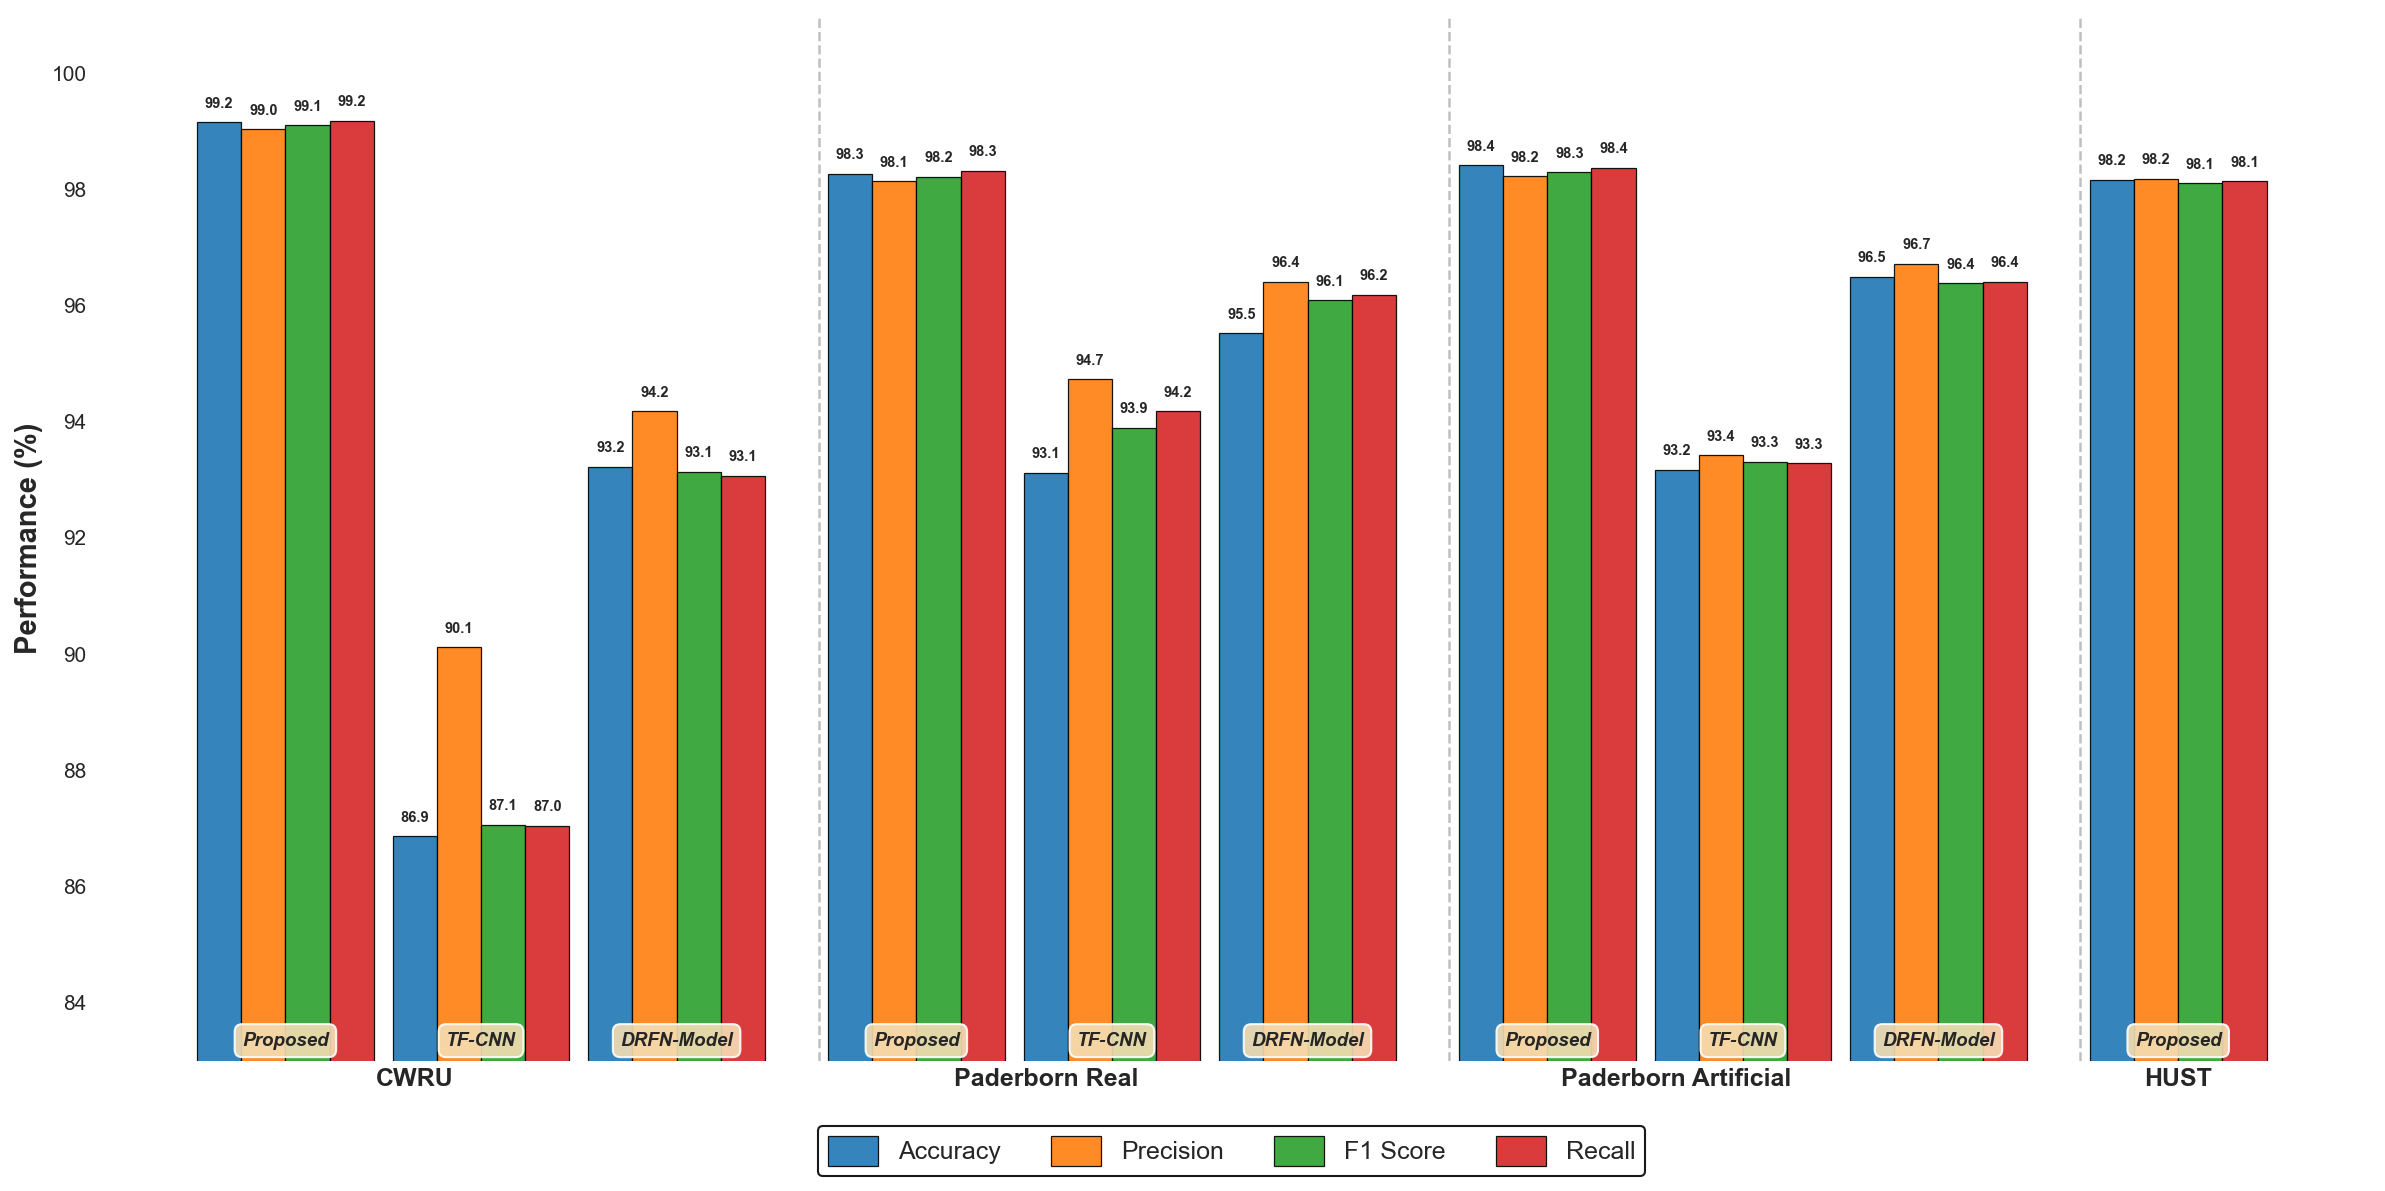

✓ Bar plot saved as 'performance_comparison_final.png'


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
datasets = ['CWRU', 'Paderborn Real', 'Paderborn Artificial', 'HUST']
metrics = ['Accuracy', 'Precision', 'F1 Score', 'Recall']

# Performance data for each method
proposed_data = np.array([
    [99.15, 99.03, 99.10, 99.18],  # CWRU
    [98.27, 98.14, 98.21, 98.32],  # Paderborn Real
    [98.41, 98.22, 98.29, 98.37],  # Paderborn Artificial
    [98.16, 98.18, 98.10, 98.14]   # HUST
])

tf_cnn_data = np.array([
    [86.86, 90.12, 87.06, 87.04],  # CWRU
    [93.12, 94.73, 93.89, 94.18],  # Paderborn Real
    [93.17, 93.42, 93.31, 93.28],  # Paderborn Artificial
    [np.nan, np.nan, np.nan, np.nan]  # HUST - not available
])

drfn_data = np.array([
    [93.22, 94.18, 93.14, 93.07],  # CWRU
    [95.52, 96.41, 96.09, 96.18],  # Paderborn Real
    [96.49, 96.72, 96.38, 96.41],  # Paderborn Artificial
    [np.nan, np.nan, np.nan, np.nan]  # HUST - not available
])

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Bar settings
x = np.arange(len(datasets))
width = 0.07
gap = 0.03  # Gap between groups
group_width = (4 * width) + gap  # 4 metrics per group

# Colors for metrics
metric_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot bars for each method
methods_offset = [-group_width, 0, group_width]
method_names = ['Proposed', 'TF-CNN', 'DRFN-Model']
method_data = [proposed_data, tf_cnn_data, drfn_data]

# To track bars for legend
legend_elements = []

# Plot each method
for method_idx, (offset, method_name, data) in enumerate(zip(methods_offset, method_names, method_data)):
    for metric_idx, (metric, color) in enumerate(zip(metrics, metric_colors)):
        positions = x + offset + metric_idx * width
        values = data[:, metric_idx]
        
        # Create bars
        bars = ax.bar(positions, values, width, 
                     color=color, alpha=0.9, 
                     edgecolor='black', linewidth=0.6)
        
        # Add to legend only once per metric (from first method)
        if method_idx == 0:
            legend_elements.append(bars[0])
        
        # Add value labels on bars (only for visible values)
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                       f'{val:.1f}', ha='center', va='bottom', 
                       fontsize=7, rotation=0, fontweight='bold')

# Add method labels below bars (skip TF-CNN and DRFN-Model for HUST)
for idx, (pos, method_name) in enumerate(zip(methods_offset, method_names)):
    for i, dataset_pos in enumerate(x):
        # Skip TF-CNN and DRFN-Model labels for HUST (index 3)
        if i == 3 and method_name in ['TF-CNN', 'DRFN-Model']:
            continue
        
        center_pos = dataset_pos + pos + (3 * width) / 2
        
        ax.text(center_pos, 83.5, method_name, 
               ha='center', va='top', fontsize=9, 
               fontweight='bold', style='italic',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', 
                        alpha=0.9))

# Customize plot
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')

# Custom x-axis labels with special positioning for HUST
ax.set_xticks(x)
# Create custom labels - HUST needs to be centered over its group
custom_labels = datasets.copy()
ax.set_xticklabels(custom_labels, fontsize=12, fontweight='bold')

# Manually adjust HUST label position to center it over the Proposed group
# Get the current tick positions
tick_positions = ax.get_xticks()
# Calculate the center of HUST Proposed group
hust_proposed_center = x[3] + methods_offset[0] + (3 * width) / 2

# Clear and reset x-ticks with adjusted HUST position
new_tick_positions = list(tick_positions[:3]) + [hust_proposed_center]
ax.set_xticks(new_tick_positions)
ax.set_xticklabels(datasets, fontsize=12, fontweight='bold')

ax.set_ylim([83, 101])

# Remove grid
ax.grid(False)

# Add vertical separators between datasets at the correct midpoint
for i in range(len(datasets)-1):
    if i == 0:  # Between CWRU and Paderborn Real
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    elif i == 1:  # Between Paderborn Real and Paderborn Artificial
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    elif i == 2:  # Between Paderborn Artificial and HUST
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    
    ax.axvline(x=separator_pos, color='gray', linestyle='--', linewidth=1.2, alpha=0.5)

# Create legend with horizontal orientation below x-axis
legend = ax.legend(legend_elements, metrics, 
                   loc='upper center', 
                   bbox_to_anchor=(0.5, -0.05),
                   ncol=4, 
                   fontsize=12,
                   frameon=True,
                   columnspacing=2,
                   handlelength=2,
                   handleheight=1.5)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_edgecolor('black')

plt.tight_layout()
plt.savefig('performance_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar plot saved as 'performance_comparison_final.png'")

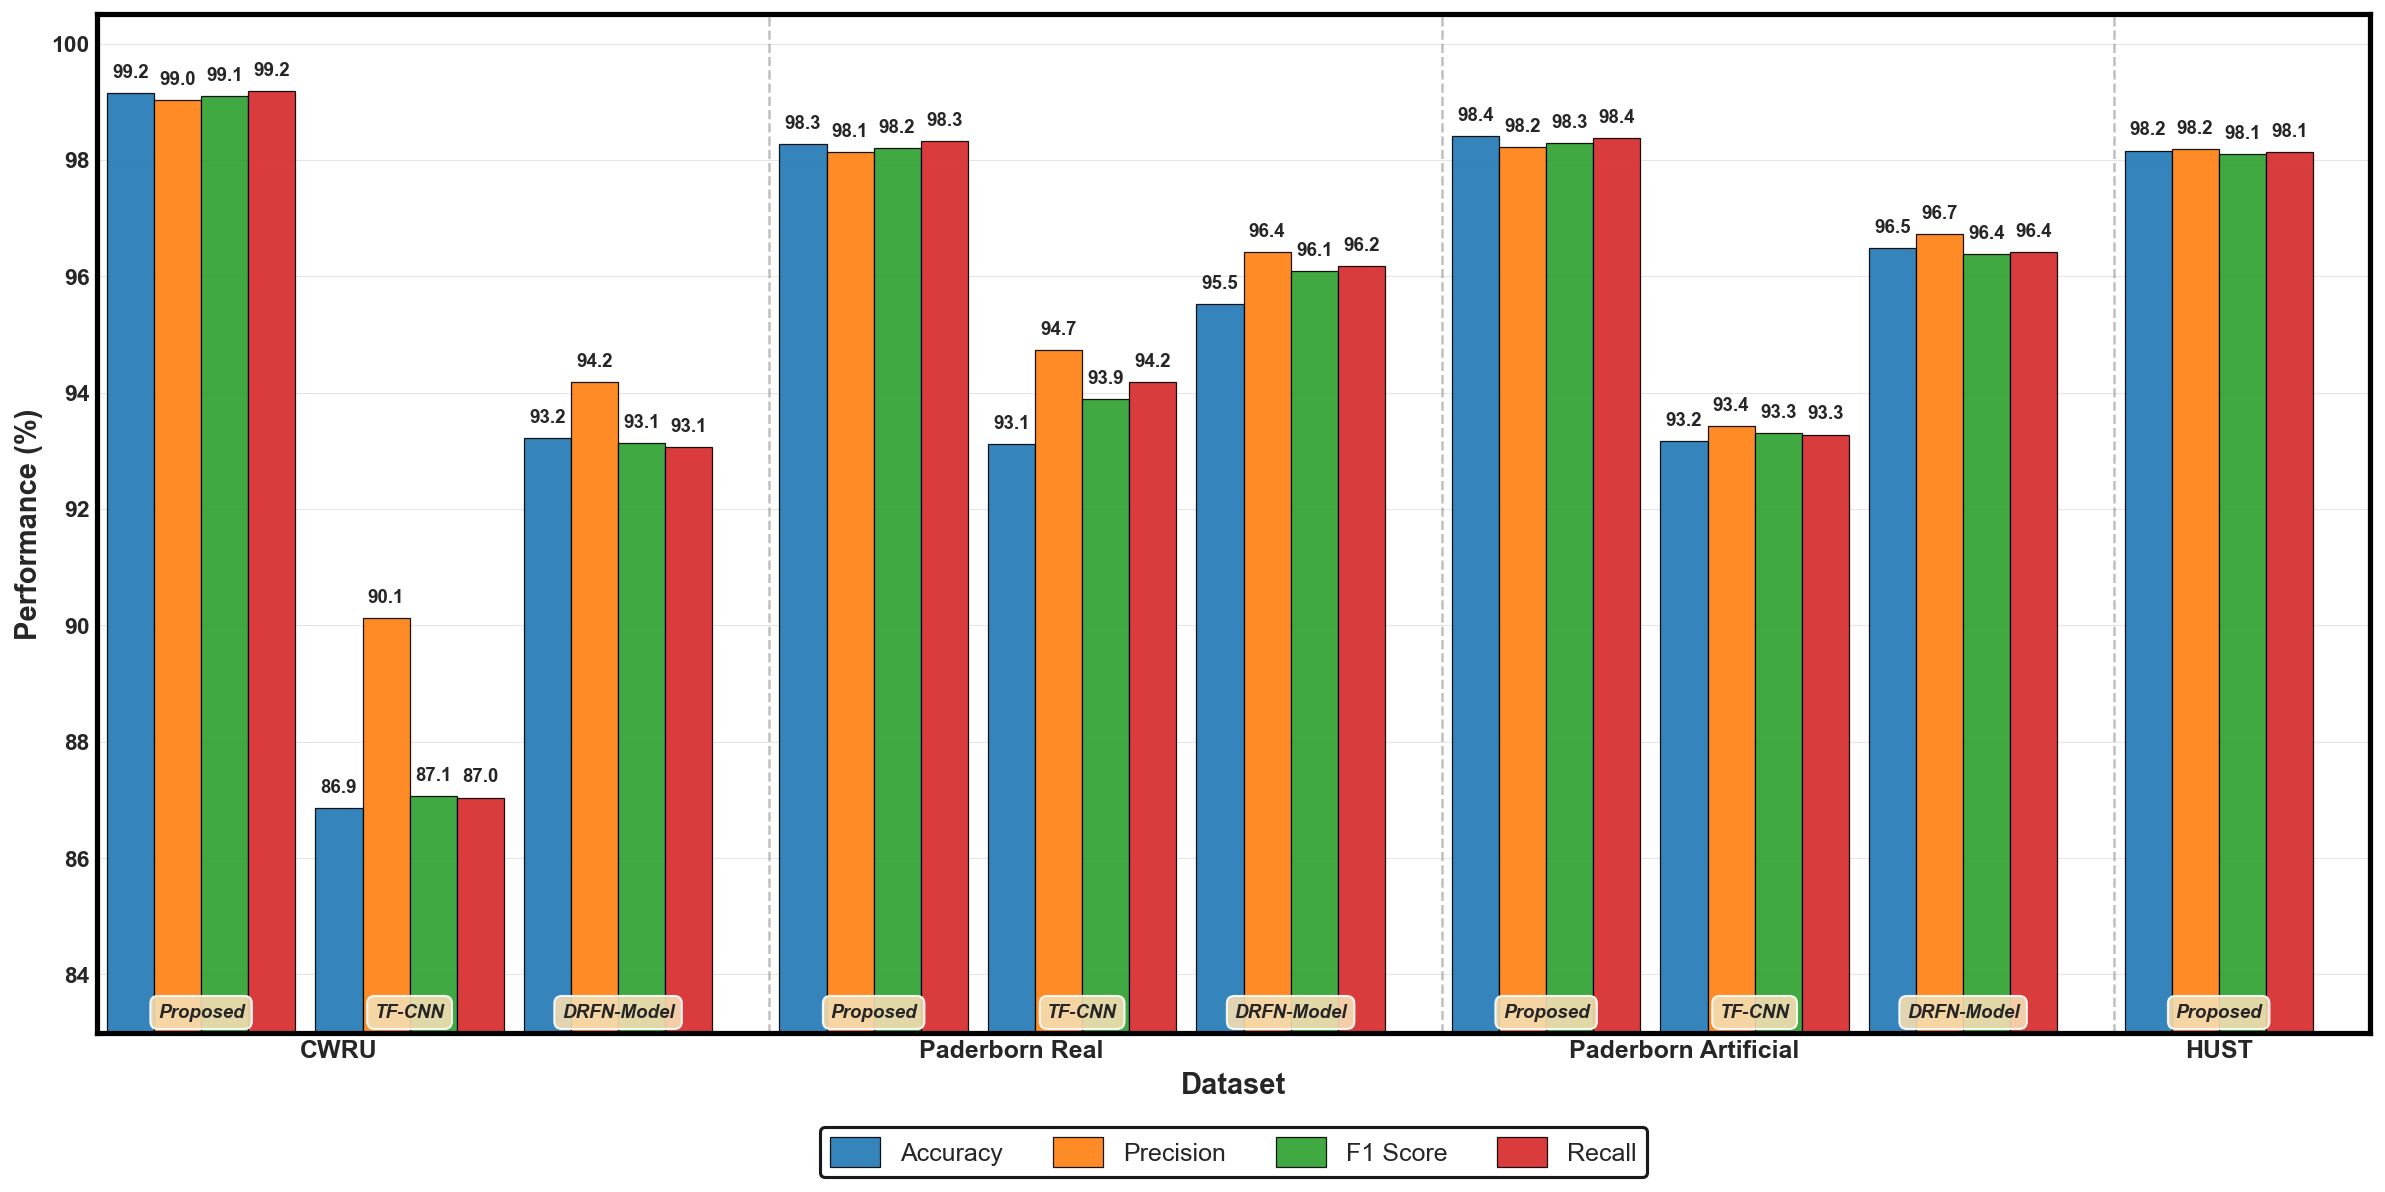

✓ Bar plot saved as 'performance_comparison_final.png'


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
datasets = ['CWRU', 'Paderborn Real', 'Paderborn Artificial', 'HUST']
metrics = ['Accuracy', 'Precision', 'F1 Score', 'Recall']

# Performance data for each method
proposed_data = np.array([
    [99.15, 99.03, 99.10, 99.18],  # CWRU
    [98.27, 98.14, 98.21, 98.32],  # Paderborn Real
    [98.41, 98.22, 98.29, 98.37],  # Paderborn Artificial
    [98.16, 98.18, 98.10, 98.14]   # HUST
])

tf_cnn_data = np.array([
    [86.86, 90.12, 87.06, 87.04],  # CWRU
    [93.12, 94.73, 93.89, 94.18],  # Paderborn Real
    [93.17, 93.42, 93.31, 93.28],  # Paderborn Artificial
    [np.nan, np.nan, np.nan, np.nan]  # HUST - not available
])

drfn_data = np.array([
    [93.22, 94.18, 93.14, 93.07],  # CWRU
    [95.52, 96.41, 96.09, 96.18],  # Paderborn Real
    [96.49, 96.72, 96.38, 96.41],  # Paderborn Artificial
    [np.nan, np.nan, np.nan, np.nan]  # HUST - not available
])

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Bar settings
x = np.arange(len(datasets))
width = 0.07
gap = 0.03  # Gap between groups
group_width = (4 * width) + gap  # 4 metrics per group

# Colors for metrics
metric_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot bars for each method
methods_offset = [-group_width, 0, group_width]
method_names = ['Proposed', 'TF-CNN', 'DRFN-Model']
method_data = [proposed_data, tf_cnn_data, drfn_data]

# To track bars for legend
legend_elements = []

# Plot each method
for method_idx, (offset, method_name, data) in enumerate(zip(methods_offset, method_names, method_data)):
    for metric_idx, (metric, color) in enumerate(zip(metrics, metric_colors)):
        positions = x + offset + metric_idx * width
        values = data[:, metric_idx]
        
        # Create bars
        bars = ax.bar(positions, values, width, 
                     color=color, alpha=0.9, 
                     edgecolor='black', linewidth=0.6)
        
        # Add to legend only once per metric (from first method)
        if method_idx == 0:
            legend_elements.append(bars[0])
        
        # Add value labels on bars (only for visible values) - LARGER and BOLDER
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                       f'{val:.1f}', ha='center', va='bottom', 
                       fontsize=9, rotation=0, fontweight='bold')

# Add method labels below bars (skip TF-CNN and DRFN-Model for HUST)
for idx, (pos, method_name) in enumerate(zip(methods_offset, method_names)):
    for i, dataset_pos in enumerate(x):
        # Skip TF-CNN and DRFN-Model labels for HUST (index 3)
        if i == 3 and method_name in ['TF-CNN', 'DRFN-Model']:
            continue
        
        center_pos = dataset_pos + pos + (3 * width) / 2
        
        ax.text(center_pos, 83.5, method_name, 
               ha='center', va='top', fontsize=9, 
               fontweight='bold', style='italic',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', 
                        alpha=0.9))

# Customize plot
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')

# Add "Dataset" label on x-axis
ax.set_xlabel('Dataset', fontsize=14, fontweight='bold')
# Custom x-axis labels with special positioning for HUST
ax.set_xticks(x)
custom_labels = datasets.copy()
ax.set_xticklabels(custom_labels, fontsize=12, fontweight='bold')

# Custom x-axis labels with special positioning for HUST
ax.set_xticks(x)
custom_labels = datasets.copy()
ax.set_xticklabels(custom_labels, fontsize=12, fontweight='bold')

# Manually adjust HUST label position to center it over the Proposed group
tick_positions = ax.get_xticks()
hust_proposed_center = x[3] + methods_offset[0] + (3 * width) / 2
new_tick_positions = list(tick_positions[:3]) + [hust_proposed_center]
ax.set_xticks(new_tick_positions)
ax.set_xticklabels(datasets, fontsize=12, fontweight='bold')

ax.set_ylim([83, 100.5])

# Make y-axis tick labels bold
ax.tick_params(axis='y', labelsize=11, width=1.5)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Add horizontal grid lines (solid, light gray)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='gray')
ax.set_axisbelow(True)  # Put grid behind bars

# Remove x-axis grid
ax.xaxis.grid(False)

# Add vertical separators between datasets (dashed lines)
for i in range(len(datasets)-1):
    if i == 0:  # Between CWRU and Paderborn Real
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    elif i == 1:  # Between Paderborn Real and Paderborn Artificial
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    elif i == 2:  # Between Paderborn Artificial and HUST
        left_edge = x[i] + methods_offset[0]
        right_edge = x[i] + methods_offset[2] + 4 * width
        next_left = x[i+1] + methods_offset[0]
        separator_pos = (right_edge + next_left) / 2
    
    ax.axvline(x=separator_pos, color='gray', linestyle='--', linewidth=1.2, alpha=0.5)

# Set x-axis limits with minimal padding to avoid overlap
leftmost = x[0] + methods_offset[0] - 0.05  # Small padding at the start
rightmost = x[3] + methods_offset[0] + 4 * width + 0.05  # Small padding at the end
ax.set_xlim([leftmost, rightmost])

# Add bold black rectangular border around the entire plot area
from matplotlib.patches import Rectangle
# Get the current axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a rectangle that covers the entire plot area
rect = Rectangle((xlim[0], ylim[0]), 
                 xlim[1] - xlim[0], 
                 ylim[1] - ylim[0],
                 linewidth=1.5, 
                 edgecolor='black', 
                 facecolor='none',
                 zorder=100)  # High zorder to ensure it's on top
ax.add_patch(rect)

# Also make the spine (frame) bold
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_edgecolor('black')

# Create legend with horizontal orientation below x-axis
legend = ax.legend(legend_elements, metrics, 
                   loc='upper center', 
                   bbox_to_anchor=(0.5, -0.08),
                   ncol=4, 
                   fontsize=12,
                   frameon=True,
                   columnspacing=2,
                   handlelength=2,
                   handleheight=1.5)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig('performance_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar plot saved as 'performance_comparison_final.png'")